#AlexNet 실습 코드

모델마다 함께 해야할 친구들이 다름  
예를들어 한컴아카데미엔 학습매니저, 강사, 청소 아주머니, 근처 식당 사장... 이 있어야 우리가 학습을 하는것처럼...  

각각의 역할을 하는 친구들이 필요함 그리고 그 친구들을 필요할 때마다 불러서 사용할줄 알아야함


## 🧠torch — 두뇌 담당 친구

모든 계산의 기본! 숫자(텐서) 다루는 걸 담당해요

```pythontorch.tensor([1, 2, 3])  # 숫자 덩어리 만들기```  
---
## 🏗️torch.nn — 건축가 친구

신경망 레이어(층)를 쌓아서 모델 구조를 만들어요

```
pythonnn.Linear(...)  # 층 만들기
nn.Conv2d(...)  # 이미지용 층 만들기
```  
---
##🏋️torch.optim — 트레이너 친구

모델이 틀렸을 때 "이렇게 고쳐!" 하고 가중치를 업데이트해줘요
```
optim.SGD(...)   # 훈련 방식 중 하나
optim.Adam(...)  # 훈련 방식 중 하나
```
---
##📦torchvision — 창고지기 친구

이미지 데이터셋(CIFAR-10 등)을 보관하고 꺼내줘요
```
torchvision.datasets.CIFAR10(...)  # CIFAR-10 데이터 꺼내기
```
---
##✂️transforms — 요리사 친구

이미지를 모델이 먹기 좋게 "손질"해줘요
```
pythontransforms.ToTensor()    # 이미지를 숫자로 변환
transforms.Normalize()   # 숫자 범위를 균일하게 맞춰줌
```
---
##🚚DataLoader — 배달부 친구

데이터를 조금씩 나눠서 모델한테 배달해줘요
```
pythonDataLoader(dataset, batch_size=32)  # 32개씩 묶어서 전달
```

#알렉스넷의 전체 단계와  
##각 단계마다 필요한 친구들


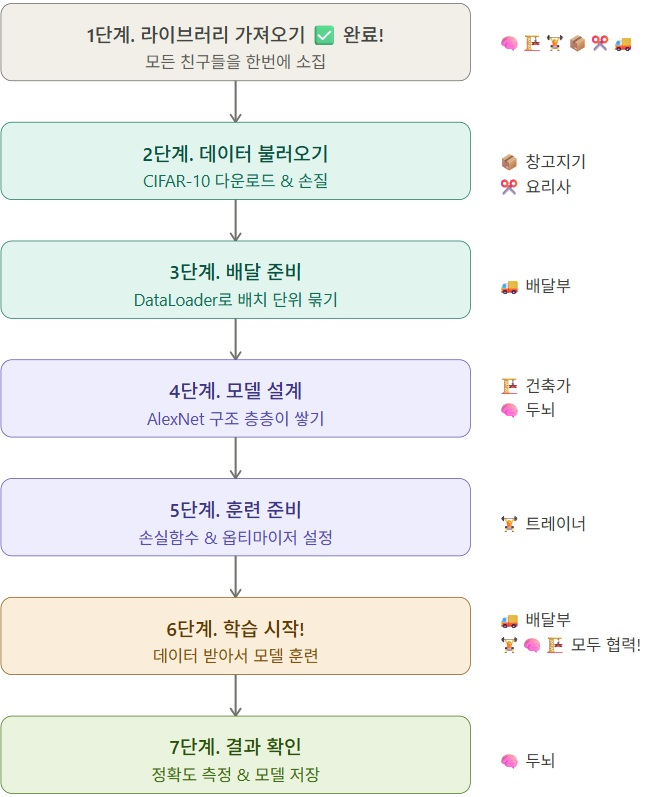

### 1. 라이브러리 가져오기(친구들 소집)

In [ ]:
import torch                          # PyTorch 기본 라이브러리
import torch.nn as nn                 # 신경망 레이어들 (Conv, Linear 등)
import torch.optim as optim           # 옵티마이저 (SGD, Adam 등)
import torchvision                    # 이미지 데이터셋, 변환 도구
import torchvision.transforms as transforms  # 이미지 전처리
from torch.utils.data import DataLoader      # 데이터 배치 로딩
from torch.utils.data import Subset # 데이터 잘라쓰기(너무 많음으로)

#시각화
import matplotlib.pyplot as plt            # 그래프 그리기
from tqdm import tqdm  # 로딩바

`as`는 "별명 붙이기"!  
마치 친구 이름이 "엄선우" 인데 부르기 귀찮아서 "엄쌤" 라고 부르는 것과 똑같아요.

```
import torch                    # 이름이 짧아서 그냥 torch로 써요
import torch.nn as nn           # torch.nn → nn 으로 줄임
import torch.optim as optim     # torch.optim → optim 으로 줄임
import torchvision              # 짧아서 그냥 써요
import torchvision.transforms as transforms  # 너무 길어서 transforms로 줄임
```

## 2단계. 데이터 불러오기(다운로드 및 손질)
(📦 창고지기랑 ✂️ 요리사 친구)

In [ ]:
# ✂️ 요리사 친구가 이미지를 손질하는 방법을 정해요
# transform = 요리 플랜을 담은 객체
# (*Compose* = 순서대로 뭘 할지 적어놓은 플래너)

# ✅ [수정] 학습용/테스트용 transform을 따로 만들었어요
# 학습용엔 데이터 증강을 추가 — 같은 이미지를 매번 다르게 보여줘서 외우는 걸 방지!
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),              # 50% 확률로 좌우 반전 (뒤집어서 보여주기)
    transforms.RandomCrop(32, padding=4),           # 랜덤으로 잘라내기 (살짝 다른 구도로 보여주기)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 밝기/대비를 랜덤하게 변환
    transforms.ToTensor(),       # 사진을 숫자(텐서)로 변환
    transforms.Normalize(        # 숫자 범위를 균일하게 맞춤
        mean=(0.5, 0.5, 0.5),   # R, G, B 평균값
        std=(0.5, 0.5, 0.5)     # R, G, B 표준편차
    )
])

# 테스트용은 증강 없이 그대로! 시험볼 땐 원본 그대로 평가해야 정확해요
test_transform = transforms.Compose([
    transforms.ToTensor(),       # 사진을 숫자(텐서)로 변환
    transforms.Normalize(        # 숫자 범위를 균일하게 맞춤
        mean=(0.5, 0.5, 0.5),   # R, G, B 평균값
        std=(0.5, 0.5, 0.5)     # R, G, B 표준편차
    )
])

##🤔 왜 Normalize를 하나요?  
컴퓨터는 원래 이미지를 0~255 숫자로 봐요.  
그냥 학습하면 숫자가 너무 들쭉날쭉해서 모델이 힘들어해요 😵  
그래서 요리사가 -1 ~ 1 사이로 균일하게 손질해주는 거예요!
```
원본:   [0, 128, 255]
손질 후: [-1.0, 0.0, 1.0]  ← 훨씬 깔끔하죠?
-------------------------------------------------

mean=0.5 는 중간을 0으로 맞추고,
std=0.5 는 범위를 -1~1로 늘려줘요!  

before (0~1):    |----|----|
                 0   0.5   1

after (-1~1):    |----|----|
                -1    0    1
                     👆 중간이 0으로 이동!
```

### 이 transform 객체는 어떻게 쓰이나?
### 나중에 창고지기한테 플래너를 건네줌
```
dataset = CIFAR10(transform=transform)
#                           👆
#                "이 플래너대로 손질해줘!"
```

In [ ]:
# 📦 창고지기 친구가 데이터를 꺼내와요
# 데이터(재료)를 꺼내와서 어떻게 사용할건지 적고,
# train_dataset과 test_dataset으로 포장해두기

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',       # 데이터 저장할 폴더
    train=True,          # True = 학습용, False = 테스트용
    download=True,       # 없으면 자동으로 다운로드
    transform=train_transform  # ✅ [수정] 학습용 transform (증강 있음)
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,         # 테스트용 데이터
    download=True,
    transform=test_transform   # ✅ [수정] 테스트용 transform (증강 없음)
)

# 전체 데이터 중 일부만 잘라서 사용 (속도 향상)
train_dataset = Subset(train_dataset, range(20000))  # 학습용 20000장
test_dataset = Subset(test_dataset, range(3000))    # 테스트용 3000장

## 3단계. 🚚 배달부 — DataLoader  

배달부 친구는 데이터를 한번에 다 배달하지 않아요!
조금씩 나눠서 배달해요 😊

In [ ]:
train_loader = DataLoader(
    train_dataset,  # 📦 어떤 포장을 가져올지(학습용)
    batch_size=64,  # 🚚 한번에 64개씩 배달
    shuffle=True    # 🔀 배달 순서를 랜덤으로 섞기
)

test_loader = DataLoader(
    test_dataset,   # 📦 어떤 포장을 가져올지(테스트용)
    batch_size=64,
    shuffle=False   # 🔀 테스트는 섞으면 안돼요!
)

### 질문) 왜 한번에 다 안 보내요? 🤔

`CIFAR-10 전체 = 5만장`  

5만장을 한꺼번에 컴퓨터 메모리에 올리면?  

`💥 메모리 터짐!`  

그래서 64장씩 나눠서 배달하는 거예요!

### 질문) 왜 shuffle=True야? 🤔  

만약 순서대로 학습하면?  
```
1~1000번  → 🐶 강아지만 학습
1001~2000번 → 🚗 자동차만 학습
```  

모델이 편식하게 돼요! 😵  

섞어주면?  

`🐶 🚗 ✈️ 🐶 🚢 🚗 ✈️ ...  → 골고루 학습!`

  ---
###질문) 그럼 테스트는???  
섞어도 결과가 같아요!
근데 비교하기 편하려고 False로 쓰는 게 관례예요 😊

### 데이터 샘플 확인  
내가 불러온 데이터가 맞는지 눈으로 확인

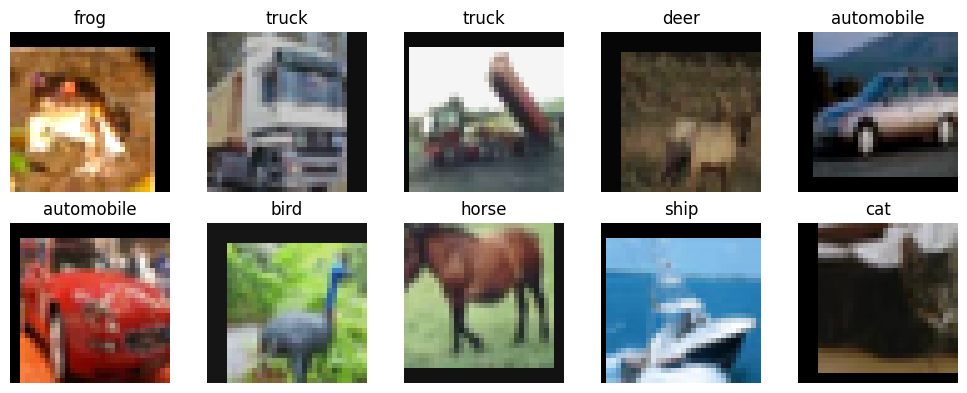

In [ ]:
# 📸 데이터 샘플 확인 — 내가 불러온 데이터가 제대로 됐는지 눈으로 확인
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = img * 0.5 + 0.5            # Normalize 되돌리기 (안하면 색이 이상하게 나옴)
    ax.imshow(img.permute(1, 2, 0))  # (C, H, W) → (H, W, C) 로 바꾸기
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

##4단계. 🏗️ 건축가 — AlexNet 모델 설계  
이제 진짜 AlexNet을 층층이 쌓을 차례예요! 🎉

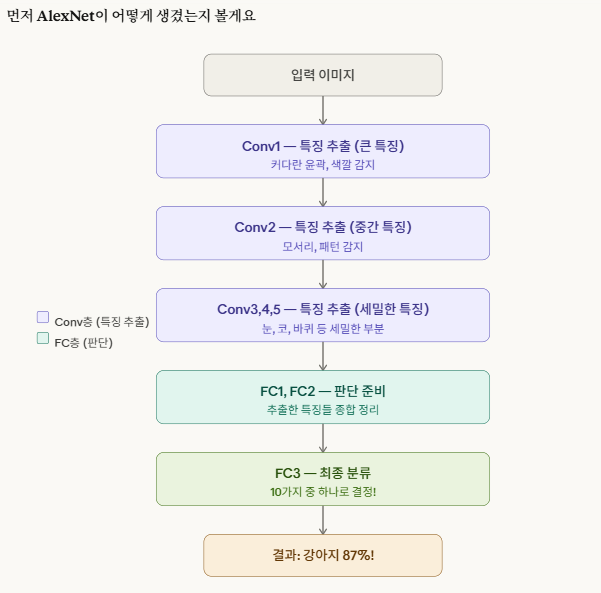

##🏗️ 건축가가 쌓는 층은 크게 두 종류예요
🟣 Conv층 (합성곱층) — 사진에서 특징을 뽑아내는 층  
```
처음엔 큰 특징 (윤곽, 색깔)
점점 세밀한 특징 (눈, 코, 바퀴...)
```

🟢 FC층 (완전연결층) — 뽑아낸 특징으로 최종 판단하는 층  

`"이 특징들 종합하면... 강아지야!"`

아래부터는 클래스에 대해 알아야 이해하기 쉬워요

### 질문) 클래스가 뭔가요?

일상으로 비유하면  
```
붕어빵 틀    →   붕어빵
  (클래스)        (객체)
```
붕어빵 틀 하나로 붕어빵을 무한정 찍어낼 수 있죠?  
클래스도 똑같아요!

---
```
pythonclass AlexNet(nn.Module):
#             👆         👆
#      내가 쓸 틀 이름  물려받는 틀
```  
`AlexNet` → 우리가 만드는 붕어빵 틀 이름  
`nn.Module` → PyTorch가 미리 만들어둔 기본 틀  
즉 기본 틀을 물려받아서 우리 입맛대로 바꾸는 거예요!

### 질문) 물려받는다는게 무슨 말이죠?
```
nn.Module 기본 틀:
  ✅ 학습 기능
  ✅ 저장 기능
  ✅ GPU 이동 기능
  ...

AlexNet 틀:
  ✅ 학습 기능     ← nn.Module한테 물려받음
  ✅ 저장 기능     ← nn.Module한테 물려받음
  ✅ GPU 이동 기능 ← nn.Module한테 물려받음
  ✅ Conv층        ← 우리가 직접 추가!
  ✅ FC층          ← 우리가 직접 추가!
```

즉 이미 만들어진 기능을 공짜로 쓰는 것!

###질문) __init__ 이랑 forward 는 뭐야?  
```
pythonclass AlexNet(nn.Module):

    def __init__(self):       # 🔧 붕어빵 틀 설계
        # "이 붕어빵 틀은
        #  이런 모양이야!" 라고 정의

    def forward(self, x):    # 🌊 반죽이 흘러가는 길
        # "반죽이 들어오면
        #  이 순서대로 구워!" 라고 정의
```

```
__init__ → 틀을 어떻게 생겼는지 정의  
forward → 데이터가 어떻게 흘러가는지 정의
```

###질문) `self` 랑 `super`는 뭐야??

self는 '나' 자신을 가리키는 말
```
class 강아지:
    def __init__(self):
        self.이름 = "뽀삐"   # '내' 이름을 self.이름 안에 저장
        self.나이 = 3        # '내' 나이를 self.나이 안에 저장

    def 자기소개(self):
        print(f"나는 {self.이름}이고 {self.나이}살이야!")
        #              👆 내 이름 꺼내기  👆 내 나이 꺼내기
```

```
뽀삐 = 강아지() 클래스
뽀삐.자기소개()
# 출력: 나는 뽀삐이고 3살이야!
```

###질문) `super()` 는 뭔가요?

`super() = "부모한테 물려받은 것 먼저 챙기기"`  
```
pythonclass 동물:                    # 부모 클래스
    def __init__(self):
        self.다리 = 4          # 모든 동물은 다리 4개

class 강아지(동물):            # 동물을 물려받은 자식 클래스
    def __init__(self):
        super().__init__()     # 👈 부모꺼 먼저 챙기기!
        self.이름 = "뽀삐"     # 그 다음 내꺼 추가
python뽀삐 = 강아지()
print(뽀삐.다리)   # 4  ← 부모한테 물려받은 것!
print(뽀삐.이름)   # 뽀삐 ← 내가 추가한 것!
```  

###질문) `super()` 없으면 어떻게 돼요?
```
pythonclass 강아지(동물):
    def __init__(self):
        # super().__init__() 을 빼면?
        self.이름 = "뽀삐"
```
```
뽀삐 = 강아지()
print(뽀삐.다리)   # ❌ 오류! 다리가 없어요!
```
부모꺼를 안 챙겼으니까 물려받은 다리가 없어요!

In [ ]:
class AlexNet(nn.Module):  # 🏗️ 건축가가 만든 설계도(특징추출과 판단까지 순서를 적은 매뉴얼 클래스)
    def __init__(self): # init = 상세 플래너(각 플래너의 상세 내용 기록)
        super().__init__()  # super = 부모 설계도 먼저 불러오기

        # 🟣 Conv층 — 특징 추출 구역
        self.features = nn.Sequential( # self.features = 부모님꺼 말고 내거!
                      # nn.Sequential = 특징 뽑는 플래너, 앞에서 Compose는 요리사의 플래너였죠?
                      # sef.features를 입력하면 아래 적어둔 순서대로 플랜을 실행합니다.
            # Conv1 — 큰 특징 감지
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            # R G B(3), 뽑아낼 특징의 수(64), 돋보기의 크기(3x3), 주변에 빈칸(1)칸씩 만들어서 진행
            nn.ReLU(),
            # conv가 뽑아낸 특징에서 양수만 골라서 다듬어주는 친구
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 2x2의 커널 사이즈로 2칸씩 다니면서 Max 값으로 압축!

            # Conv2 — 중간 특징 감지
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            # 위에 Conv1에서 받은 64개의 특징을 받아서 진행해 192개의 특징 뽑아내기
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3,4,5 — 세밀한 특징 감지
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            # 위에 Conv1에서 받은 192개의 특징을 받아서 진행해 384개의 특징 뽑아내기
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 🟢 FC층 — 🧑‍⚖️ 최종 판사!
        # nn.Sequential = 판단 플래너
        # 아래는 판사가 이게 뭔지 판단하기 위해 적어둔 '판사의 재판 플래너'
        # self.classifier 을 입력하면 아래 적어둔 순서대로 판단 플랜을 시작
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                 # 과적합 방지 (0.5 = 절반의 뉴런을 랜덤으로 끄기)
            nn.Linear(256 * 4 * 4, 4096),    # FC1 (쉽게 지방법원)
            # 리니어에서 256 * 4 * 4 라고 표현하는 이유는, 어디서 왔는지 알아보기 쉬우려고
            nn.ReLU(),                       # 의미 없는 판단을 0으로
            nn.Dropout(0.5),                 # ✅ [수정] 0.5 명시 (기본값이지만 명확하게 적기)
            nn.Linear(4096, 4096),           # FC2 (고등법원)
            nn.ReLU(),
            nn.Linear(4096, 10),             # FC3 (대법원) — 최종 10개 분류
        )

    def forward(self, x):             # 플래너 읽는 순서(데이터가 들어오면 이 대로 통과해!)
        x = self.features(x)          # 특징 추출하는 친구의 플래너 거치고
        x = x.view(x.size(0), -1)     # 쫙 ~ 펼쳐서
        x = self.classifier(x)        # 판단하는 판사의 플래너를 통과해
        return x

### 질문) 렐루가 뭐에요?
ReLU = 음수는 0, 양수는 그대로!  
"없는 특징은 깔끔하게 버려!" 🗑️

`pythonnn.ReLU()`

딱 이 규칙 하나예요!
```
0보다 작으면 → 0
0보다 크면   → 그대로
```
즉 의미있는 정보만 남기기 위해 사용함

마지막 FC3에선 판단을 해야하기 때문에 ReLU 사용 x   
음수를 0으로 만들면 확률 계산이 망가짐

Conv랑 ReLU는 항상 같이 다녀요  
```
pythonnn.Conv2d(...),   # 특징 뽑기
nn.ReLU(),        # 없는 특징 정리
nn.Conv2d(...),   # 특징 뽑기
nn.ReLU(),        # 없는 특징 정리
```
```
Conv = 특징 뽑는 친구
ReLU = 뒤에서 정리해주는 친구
```
항상 붙어다니는 단짝이에요! 👫


### 질문) MaxPool이 뭐에요?  
이미지를 작게 압축해 주는 친구에요

큰 숫자 = "여기 특징이 강하게 있어!"  
작은 숫자 = "여기 특징이 약해..."  

가장 강한 특징만 남기는 거예요!

```
 원본 4x4:                           압축 후 2x2:

┌──┬──┬──┬──┐         ┌──┬──┐
│ 1  │ 3  │ 2  │ 4  │         │ 3  │ 4  │
│ 2  │ 1  │ 1  │ 2  │  →     ├──┼──┤
├──┼──┼──┼──┤         │ 6  │ 8  │
│ 5  │ 6  │ 7  │ 8  │         └──┘──┘
│ 1  │ 2  │ 3  │ 1  │
└──┴──┴──┴──┘

왼쪽위 [1,3,2,1] → 최대값 3
오른쪽위 [2,4,1,2] → 최대값 4
왼쪽아래 [5,6,1,2] → 최대값 6
오른쪽아래 [7,8,3,1] → 최대값 8
```

```
Conv → ReLU → MaxPool 흐름
🖼️ 이미지
    ↓
Conv2d   → 특징 뽑기
    ↓
ReLU     → 없는 특징 정리
    ↓
MaxPool  → 핵심만 압축
    ↓
🗜️ 작아진 이미지
```
세 친구가 항상 이 순서로 일해요

###질문) Linear는 뭐에요??

리니어에 대해 이야기 하기 전에  
`x = x.view(x.size(0), -1)` 설명  

```
features 를 다 통과하면 이런 덩어리가 나와요
256개 채널 × 4 × 4 크기
= 4096개의 숫자 덩어리
```

즉 3차원의 숫자 덩어리  
하지만 리니어는 판단을 해야하기 때문에 세세하게 봐야함  
그래서 [1, 2, 3, 4, 5, 6, 7,.....] 같이 1줄로 쭉 펼쳐서 전달해야함  
`x = x.view(x.size(0), -1)`를 통해 1줄로 펴는 과정을 거쳐요

---

`Linear`는 입력한 4096개의 값이랑 출력해야할 값을 모두 연결시키는 역할을 해요

features 는 이미지를 구역별로 봤어요  
"왼쪽에 귀가 있네!"  
"오른쪽에 꼬리가 있네!"

이 특징들을 가지고 `Linear` 는 전부 연결해서 종합 판단해요  

"귀도 있고 꼬리도 있고 코도 있으니까  
 → 강아지야!" 🐕  

따로따로 본 특징들을 한번에 종합하는 거예요!




## 5단계. 🏋️ 트레이너 — 훈련 준비  
모델을 학습시키려면 두 가지가 필요해요

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용중인 장치: {device}")  # 확인용

model = AlexNet().to(device)  # 모델을 GPU로 이동!

# 1. 손실함수 — 얼마나 틀렸는지 측정(채점관)
criterion = nn.CrossEntropyLoss()
# nn(위에서 줄여놓은 torch.nn)에서 CrossEntropyLoss라는 채점관을 데려와서
# 'criterion'이라는 객체 생성 >> criterion은 (판단·결정·평가의 '기준(척도)'을 뜻함)
# 즉 여기서 criterion은 정답과 예측값의 차이 >> '오차'를 뜻함

# 2. 옵티마이저 — 틀린 만큼 고치기(수리공)
optimizer = optim.SGD(   # SGD라는 수리공을 데려와서 'optimizer'라는 객체 생성
    model.parameters(),  # 어디를 고칠지(Conv or Linear 등등.. 컴퓨터가 알아서 고침)
    lr=0.01,             # 얼마나 고칠지
    momentum=0.9,        # 관성을 얼마나 줄지
    weight_decay=1e-4    # ✅ [수정] L2 정규화 — 가중치가 너무 커지는 걸 벌칙으로 막아주는 역할
)


사용중인 장치: cuda


###질문) 손실함수가 뭐야? 🤔  
```
모델이 예측한 것      정답
["강아지 80%"]  vs  [강아지]

→ 얼마나 틀렸어? → 점수로 표현!
```

점수가 낮을수록 잘 맞춘 것이에요!

예를들어 정답이 100이고, 예측이 80이라면  
여기서의 손실은 20이에요, 예측이 95라면 손실이 5겠죠?
```
완벽히 맞춤  →  손실 0
많이 틀림    →  손실 크게
```

##질문) CrossEntropyLoss가 뭐야?  
>> 확률 채점관!
```
이렇게 채점해요
모델 예측:              정답:
강아지 80%  ✅          강아지
고양이 15%
자동차  5%

→ 정답을 80% 확신했네!
→ 손실 낮음 😊
```
```
모델 예측:              정답:
강아지 10%  ✅          강아지
고양이 60%
자동차 30%

→ 정답을 10%밖에 확신 못했네!
→ 손실 높음 😵
```

CrossEntropyLoss는 주로 분류하는 모델의 손실함수(채점관)으로 사용된다.

###질문) 옵티마이저가 뭐야? 🤔
손실 점수를 보고 가중치를 조금씩 고쳐요(수리공)
```
모델이 학습하면서 조절하는 숫자들이에요

처음엔 랜덤한 숫자
      ↓
학습하면서 조금씩 수정
      ↓
점점 정답에 가까워짐!  

옵티마이저에도 여러 종류가 있어요  
`SGD`는 기울기를 보며 조금씩 고치는 수리공  
`ADAM`은 학습률(lr)을 자동으로 조절하는 똑똑한 수리공  

요샌 `ADAM`을 많이 쓰지만 알렉스넷은 `SGD`를 썼으니 우리도 따라서 'SGD'를 사용합니다.
```

###질문) lr(학습률) 이 뭐야? 🤔
```
lr = 0.01   → 조금씩 고치기 🐢
lr = 0.1    → 크게 고치기 🐇
너무 크면 → 왔다갔다 불안정 😵
너무 작으면 → 너무 느림 🐢
0.01 이 딱 적당한 값이에요!
```

##질문) momentum(모멘텀)이 뭐야?
momentum=0.9 의 의미  
이전 방향을 90% 기억  
새 방향을   10% 반영  

→ 갑자기 방향 바꾸지 않고
  부드럽게 학습해요!  
  
갑자기 방향을 바꾸게되면 학습이 불안정해져요

##6단계. 🚚📦🏋️ 모두 협력 — "학습 루프"!  
드디어 모든 친구들이 한자리에 모여요 😊  

In [ ]:
#학습 기록용 리스트(그래프를 그리기 위함)
loss_list = []       # 손실값 기록
val_loss_list = []  # val loss 기록

for epoch in range(20):                  # 전체 데이터 10번 반복

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/20"):
        # 🚚 배달부가 64장씩 배달(사진, 라벨)
        # train_loader 데이터는 사진과 라벨(1 ~ 10까지)로 되어있음
        # 학습시킬땐 사진 보여주고 이건 1이야, 이건 3이야 이런식으로 학습을 해야함
        # 그래서 for문을 통해 차례대로 이미지와 라벨을 꺼냄

        images = images.to(device)  # 이미지를 GPU로 이동
        labels = labels.to(device)  # 라벨을 GPU로 이동

        # 1. 이전 계산 초기화
        optimizer.zero_grad()

        # 2. 🗺️ forward — 예측하기
        outputs = model(images)
        # 여기서 model = 알렉스넷() 한테 image를 넣으면 Pythorch가 자동으로 forward를 실행

        # 3. 📝 손실 계산 — 얼마나 틀렸어?
        # 모델이 예측한 10개 클래스에 대한 확률과 실제 정답(라벨)을 비교
        loss = criterion(outputs, labels)

        # 4. ↩️ backward — 어디서 틀렸는지 추적(역전파)
        loss.backward()

        # 5. 🔧 가중치 수정
        # 이 step을 적어야 수리공이 직접 가서 고침, 빼먹으면 수리 안하고 넘어감
        # 실제 업데이트가 일어나는
        optimizer.step()
        train_loss += loss.item()
    loss_list.append(train_loss / len(train_loader))  # 배치 평균으로 저장

    # val loss 계산 추가! >> 과적합 보는 코드, train loss가 줄어드는데 val loss가 올라가면 과적합
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss_v = criterion(outputs, labels)  # val loss 계산
            val_loss += loss_v.item()

    val_loss_list.append(val_loss / len(test_loader))  # 평균 val loss 저장

    print(f"{epoch+1}번째 완료! train loss: {loss:.4f} | val loss: {val_loss/len(test_loader):.4f}")


Epoch 1/20: 100%|██████████| 313/313 [00:22<00:00, 13.66it/s]


1번째 완료! train loss: 2.2141 | val loss: 2.2001


Epoch 2/20: 100%|██████████| 313/313 [00:23<00:00, 13.38it/s]


2번째 완료! train loss: 1.7385 | val loss: 1.8507


Epoch 3/20: 100%|██████████| 313/313 [00:22<00:00, 13.61it/s]


...

18번째 완료! train loss: 1.0615 | val loss: 0.7873


Epoch 19/20: 100%|██████████| 313/313 [00:21<00:00, 14.25it/s]


19번째 완료! train loss: 0.7900 | val loss: 0.7409


Epoch 20/20: 100%|██████████| 313/313 [00:21<00:00, 14.63it/s]


20번째 완료! train loss: 0.5455 | val loss: 0.7463


###질문) 에포크와 배치의 차이점은??  
에포크 : 전체 데이터 1바퀴(에포크 3 = 책 3회독)  
배치 : 한번에 보는 묶음(책을 몇번에 나눠서 읽을것인가)

###질문) 왜 계속 옵티마이저를 초기화 하나요?  

매번 새 시험지에 풀어야 해요!

zero_grad = 시험지 새로 받기 📄

이전 시험지 위에 계속 쓰면?
→ 답이 겹쳐서 엉망! 😵
```
# zero_grad 없으면

1번째 batch → gradient = 0.5
2번째 batch → gradient = 0.5 + 0.5 = 1.0  # 누적!
3번째 batch → gradient = 1.0 + 0.5 = 1.5  # 또 누적!

→ 점점 엉터리 값이 됨 😵
```

##7단계. 🧑‍⚖️ 결과 확인!  

학습이 끝난 모델이 얼마나 잘 맞추는지 확인해요!

In [ ]:
# 테스트 하는 곳!
accuracy_list = []   # 정확도 기록

correct = 0  # 맞춘 개수 업데이트용 변수
total = 0    # 전체 개수 업데이트용 변수
model.eval() # 🧑‍⚖️ 평가 모드 - Dropout 끄기 (모든 뉴런 다 켜기)
# 시험볼 땐 오답노트 적을 필요 없음>> 빨리 빨리 계산하고 넘어가야하기에
with torch.no_grad():
# 👆 'with'는 내부 룰 선언임
# "이 안에서는 gradient 계산 끄고
#  평가만 할거야!"
    for images, labels in test_loader:  # 🚚 테스트 데이터 안에있는 이미지와 라벨들을
        images = images.to(device)      # (이미지를 GPU로 이동)
        labels = labels.to(device)      # (라벨을 GPU로 이동)
        outputs = model(images)         #  훈련시킨 모델에 넣고 예측한 값을 outputs에 저장
        _, predicted = torch.max(outputs, 1) # outputs값을, 1번축(열방향) 방향으로 보면서
                                             # max 값(가장 높은 확률의 예측값)을 predicted에 저장
        total += labels.size(0)                 # 전체 개수 누적
        correct += (predicted == labels).sum()  # 맞춘 개수 누적
    accuracy = 100 * correct.cpu() / total
    # 맞춘 개수 / 전체 개수 * 100
    # = 퍼센트로 변환! >> 시각화용 코드
    print(f"최종 정확도: {accuracy:.2f}%")

최종 정확도: 73.77%


###질문) eval이 뭔가요??

Dropout이 켜져있으면 결과가 들쭉날쭉이므로
평가할땐 끄고 한다.

훈련할땐 model.train()

###질문) gradient가 뭐에요??
```
학습 = 🏋️ 운동할 때
→ 어디가 부족한지 분석 필요!
→ gradient 켜기 ✅

평가 = 🧑‍⚖️ 시험볼 때
→ 그냥 맞고 틀리고만 확인!
→ gradient 끄기 ✅
```
끄면 뭐가 좋아요?

```
gradient 켜면:
→ 계산하면서 기록을 남겨요
→ 메모리, 시간 많이 써요 😵

gradient 끄면:
→ 기록 안남겨도 돼요
→ 메모리, 시간 절약! 😊
```

시각화

/tmp/ipykernel_34794/646943155.py:10: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34794/646943155.py:10: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34794/646943155.py:10: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34794/646943155.py:10: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3

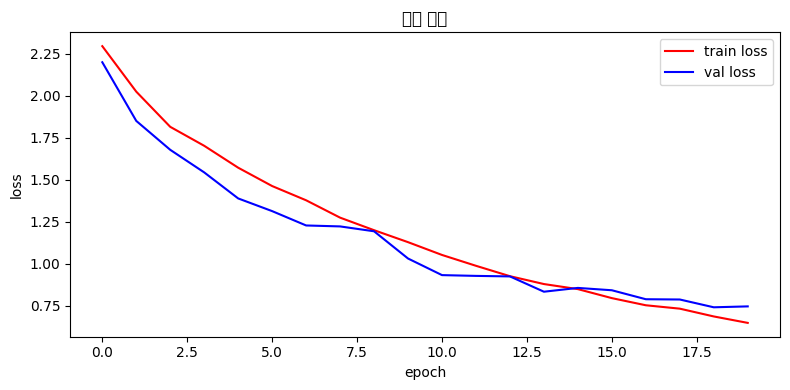

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(loss_list, color='red', label='train loss')
ax.plot(val_loss_list, color='blue', label='val loss')
ax.set_title('학습 진행')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()  # 범례 표시

plt.tight_layout()
plt.show()